In [1]:
#Maria's Script that has the chi2pid cut functions
import numpy as np

# ---------------------------------------------------------------------------
# K+ pass-2 chi2pid parameters (pid_cuts.java lines 438–439)
# ---------------------------------------------------------------------------
MU_KPLUS = 0.082
SIGMA_KPLUS = 0.985

# Lower-bound exponential parameters for p > 2 GeV/c (pid_cuts.java line 443)
LOWER_C = 1.2        # plateau value the exponential decays away from
LOWER_P0 = 2.0       # momentum at which the exponential kicks in
LOWER_TAU = 0.6      # decay constant in GeV/c

# Upper-bound exponential parameters for p > 2.5 GeV/c (pid_cuts.java line 445)
UPPER_C = 2.6        # plateau value the exponential decays away from
UPPER_P0 = 2.5       # momentum at which the upper bound starts contracting
UPPER_TAU = 0.3      # decay constant in GeV/c

# ---------------------------------------------------------------------------
# π+ pass-2 chi2pid parameters (pid_cuts.java lines 428–429)
# ---------------------------------------------------------------------------
MU_PIPLUS = -0.067
SIGMA_PIPLUS = 0.956

# Upper-bound exponential parameters for π+ at p > 3.5 GeV (pid_cuts.java line 433)
# Lower bound stays flat at μ−3σ for all p (no lower-bound exponential for π+)
PIPLUS_UPPER_C = -0.55
PIPLUS_UPPER_P0 = 3.5
PIPLUS_UPPER_TAU = 0.55


# ---------------------------------------------------------------------------
# Private helper
# ---------------------------------------------------------------------------

def _const_plus_exponential(c: float, a: float, tau: float,
                             p0: float, p: np.ndarray) -> np.ndarray:
    """
    Evaluate the helper function used by pid_cuts.java (line 263–264).

        f(p) = c + a * exp( -(p - p0) / tau )

    Parameters
    ----------
    c   : asymptotic plateau (value as p → ∞)
    a   : amplitude of the exponential term at p = p0
    tau : decay constant (GeV/c); controls how quickly the exponential falls
    p0  : reference momentum (GeV/c) at which the exponential term equals *a*
    p   : track momentum array (GeV/c)

    Returns
    -------
    np.ndarray, same shape as *p*
    """
    return c + a * np.exp(-(p - p0) / tau)


# ---------------------------------------------------------------------------
# K+ cut
# ---------------------------------------------------------------------------

def passes_kplus_chi2pid_cut(chi2pid: np.ndarray, p: np.ndarray) -> np.ndarray:
    """
    Pass-2 K+ chi2pid cut, momentum-dependent in 3 regimes.

    Direct Python translation of the K+ block in
    ``charged_hadron_pass2_chi2pid_cut`` (pid_cuts.java lines 437–447).

    Parameters
    ----------
    chi2pid : array-like
        REC::Particle.chi2pid for each track (pull of beta against K+
        hypothesis).  Can be a numpy array or any array-like (pandas Series,
        list).
    p : array-like
        Track momentum magnitude in GeV/c.

    Returns
    -------
    np.ndarray of bool, same shape as inputs. True = passes cut.

    Examples
    --------
    Apply to a pandas DataFrame::

        df["baseline_pass"] = passes_kplus_chi2pid_cut(
            df["chi2pid"].to_numpy(), df["p"].to_numpy()
        )
    """
    chi2pid = np.asarray(chi2pid, dtype=float)
    p = np.asarray(p, dtype=float)

    lo_flat = MU_KPLUS - 3.0 * SIGMA_KPLUS   # -2.873
    hi_flat = MU_KPLUS + 3.0 * SIGMA_KPLUS   # +3.037

    lo_exp = _const_plus_exponential(LOWER_C, lo_flat - LOWER_C, LOWER_TAU, LOWER_P0, p)
    hi_exp = _const_plus_exponential(UPPER_C, hi_flat - UPPER_C, UPPER_TAU, UPPER_P0, p)

    # Regime 1: p < 2  → symmetric flat window
    # Regime 2: 2 < p < 2.5 → lower bound contracts, upper stays flat
    # Regime 3: p >= 2.5 → both bounds contract
    # Note: tracks exactly at p == 2.0 are not covered by the Java branches
    # (Java uses p<2 and p>2), so they fall to the else (regime 3).
    # We replicate that behaviour with the np.where nesting below.

    lower = np.where(p < 2.0, lo_flat, lo_exp)
    upper = np.where(p < 2.5, hi_flat, hi_exp)

    return (chi2pid > lower) & (chi2pid < upper)


# ---------------------------------------------------------------------------
# π+ cut
# ---------------------------------------------------------------------------

def passes_piplus_chi2pid_cut(chi2pid: np.ndarray, p: np.ndarray) -> np.ndarray:
    """
    Pass-2 π+ chi2pid cut, momentum-dependent in 2 regimes.

    Direct Python translation of the π+ block (pid == 211) in
    ``charged_hadron_pass2_chi2pid_cut`` (pid_cuts.java lines 427–435).

    Regimes
    -------
    p < 3.5 GeV/c  : symmetric window  mu ± 3*sigma
                     lower = μ − 3σ = −2.935
                     upper = μ + 3σ = +2.801
    p ≥ 3.5 GeV/c  : lower bound stays flat at μ − 3σ = −2.935;
                     upper bound contracts exponentially, asymptoting to
                     PIPLUS_UPPER_C = −0.55 as p → ∞.
                     upper = const_plus_exponential(−0.55,
                                                    μ+3σ+0.55,
                                                    0.55, 3.5, p)

    Parameters
    ----------
    chi2pid : array-like
        REC::Particle.chi2pid for each track (pull of beta against π+
        hypothesis).  Can be a numpy array or any array-like (pandas Series,
        list).
    p : array-like
        Track momentum magnitude in GeV/c.

    Returns
    -------
    np.ndarray of bool, same shape as inputs. True = passes cut.

    Notes
    -----
    The lower bound is flat (μ − 3σ) for all momenta — the π+ cut has no
    lower-bound exponential regime, unlike K+.  The upper bound asymptotes
    to −0.55 at high momentum, reflecting the narrowing of the pion/kaon
    separation in chi2pid space.

    Examples
    --------
    Apply to a pandas DataFrame::

        df["baseline_piplus"] = passes_piplus_chi2pid_cut(
            df["chi2pid"].to_numpy(), df["p"].to_numpy()
        )
    """
    chi2pid = np.asarray(chi2pid, dtype=float)
    p = np.asarray(p, dtype=float)

    lo_flat = MU_PIPLUS - 3.0 * SIGMA_PIPLUS   # -2.935
    hi_flat = MU_PIPLUS + 3.0 * SIGMA_PIPLUS   # +2.801

    # Upper-bound exponential: asymptotes to PIPLUS_UPPER_C = -0.55
    hi_exp = _const_plus_exponential(
        PIPLUS_UPPER_C,
        hi_flat - PIPLUS_UPPER_C,       # amplitude = hi_flat + 0.55 = 3.351
        PIPLUS_UPPER_TAU,
        PIPLUS_UPPER_P0,
        p,
    )

    # Regime 1: p < 3.5 → symmetric flat window
    # Regime 2: p ≥ 3.5 → lower stays flat, upper contracts exponentially
    lower = lo_flat  # constant for all p
    upper = np.where(p < 3.5, hi_flat, hi_exp)

    return (chi2pid > lower) & (chi2pid < upper)


# ---------------------------------------------------------------------------
# Loose flat-cut reference (older, momentum-independent, species-agnostic)
# ---------------------------------------------------------------------------

def passes_loose_chi2pid_cut(chi2pid: np.ndarray, p: np.ndarray,
                              threshold: float = 3.0) -> np.ndarray:
    """
    Loose chi2pid cut: |chi2pid| < threshold (default 3).

    This is the older, momentum-independent cut.  The numeric form is
    identical for K+ and π+ (and any other species), so the function is
    provided once under a species-agnostic name.  Use it for comparison and
    orientation only — the production baseline is the species-specific
    pass-2, momentum-dependent cut (``passes_kplus_chi2pid_cut`` or
    ``passes_piplus_chi2pid_cut``).

    Parameters
    ----------
    chi2pid   : array-like, REC::Particle.chi2pid
    p         : array-like, track momentum (GeV/c) — accepted but not used
                (kept so call sites have a uniform signature)
    threshold : float, half-width of the symmetric window (default 3)

    Returns
    -------
    np.ndarray of bool
    """
    chi2pid = np.asarray(chi2pid, dtype=float)
    return np.abs(chi2pid) < threshold


# Backward-compatible alias so any existing code importing the old name works.
passes_kplus_loose_chi2pid_cut = passes_loose_chi2pid_cut


# ---------------------------------------------------------------------------
# __main__: sanity-check assertions + optional visualisation
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    import math

    # -----------------------------------------------------------------------
    # K+ spot-check assertions
    # -----------------------------------------------------------------------
    # p = 1.0, chi2pid = 0.0  →  well inside flat window → True
    assert passes_kplus_chi2pid_cut(np.array([0.0]), np.array([1.0]))[0], \
        "FAIL: p=1.0, chi2pid=0.0 should pass"

    # p = 1.0, chi2pid = -3.0  →  lower bound = -2.873; -3.0 < -2.873 → False
    assert not passes_kplus_chi2pid_cut(np.array([-3.0]), np.array([1.0]))[0], \
        "FAIL: p=1.0, chi2pid=-3.0 should NOT pass (below lower bound -2.873)"

    # p = 3.0, chi2pid = -2.0
    #   lower = 1.2 + (-4.073) * exp(-1/0.6) ≈ 0.432
    #   -2.0 < 0.432 → False
    assert not passes_kplus_chi2pid_cut(np.array([-2.0]), np.array([3.0]))[0], \
        "FAIL: p=3.0, chi2pid=-2.0 should NOT pass (below lower bound ≈ 0.432)"

    # p = 3.0, chi2pid = 1.0
    #   lower ≈ 0.432, upper = 2.6 + 0.437*exp(-0.5/0.3) ≈ 2.682
    #   0.432 < 1.0 < 2.682 → True
    assert passes_kplus_chi2pid_cut(np.array([1.0]), np.array([3.0]))[0], \
        "FAIL: p=3.0, chi2pid=1.0 should pass (between ≈0.432 and ≈2.682)"

    print("All K+ spot-check assertions passed.")

    # -----------------------------------------------------------------------
    # π+ spot-check assertions
    # -----------------------------------------------------------------------
    # Precompute flat bounds for reference in comments:
    #   lo_flat = -0.067 - 3*0.956 = -2.935
    #   hi_flat = -0.067 + 3*0.956 = +2.801

    # p = 1.0, chi2pid = 0.0  →  flat window: -2.935 < 0 < 2.801 → True
    assert passes_piplus_chi2pid_cut(np.array([0.0]), np.array([1.0]))[0], \
        "FAIL π+: p=1.0, chi2pid=0.0 should pass (well inside flat window)"

    # p = 1.0, chi2pid = 3.0  →  3.0 > hi_flat=2.801 → False
    assert not passes_piplus_chi2pid_cut(np.array([3.0]), np.array([1.0]))[0], \
        "FAIL π+: p=1.0, chi2pid=3.0 should NOT pass (above upper bound 2.801)"

    # p = 4.0, chi2pid = 0.0
    #   lower = -2.935 (flat)
    #   upper = -0.55 + 3.351 * exp(-(4.0-3.5)/0.55)
    #         = -0.55 + 3.351 * exp(-0.9091)
    #         = -0.55 + 3.351 * 0.4027 ≈ -0.55 + 1.350 ≈ 0.800
    #   -2.935 < 0.0 < 0.800 → True
    assert passes_piplus_chi2pid_cut(np.array([0.0]), np.array([4.0]))[0], \
        "FAIL π+: p=4.0, chi2pid=0.0 should pass (between -2.935 and ≈0.800)"

    # p = 5.0, chi2pid = 1.0
    #   upper = -0.55 + 3.351 * exp(-(5.0-3.5)/0.55)
    #         = -0.55 + 3.351 * exp(-2.7273) ≈ -0.55 + 0.219 ≈ -0.331
    #   chi2pid=1.0 > upper=-0.331 → False (fails upper bound)
    assert not passes_piplus_chi2pid_cut(np.array([1.0]), np.array([5.0]))[0], \
        "FAIL π+: p=5.0, chi2pid=1.0 should NOT pass (above upper bound ≈-0.331)"

    # p = 5.0, chi2pid = -1.0
    #   lower=-2.935, upper≈-0.331
    #   -2.935 < -1.0 < -0.331 → True
    assert passes_piplus_chi2pid_cut(np.array([-1.0]), np.array([5.0]))[0], \
        "FAIL π+: p=5.0, chi2pid=-1.0 should pass (between -2.935 and ≈-0.331)"

    print("All π+ spot-check assertions passed.")

    # -----------------------------------------------------------------------
    # Print cut-window tables
    # -----------------------------------------------------------------------
    p_check = np.array([1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0])

    # K+ window
    lo_flat_k = MU_KPLUS - 3.0 * SIGMA_KPLUS
    hi_flat_k = MU_KPLUS + 3.0 * SIGMA_KPLUS
    lo_exp_k = _const_plus_exponential(LOWER_C, lo_flat_k - LOWER_C, LOWER_TAU, LOWER_P0, p_check)
    hi_exp_k = _const_plus_exponential(UPPER_C, hi_flat_k - UPPER_C, UPPER_TAU, UPPER_P0, p_check)
    lower_k = np.where(p_check < 2.0, lo_flat_k, lo_exp_k)
    upper_k = np.where(p_check < 2.5, hi_flat_k, hi_exp_k)

    # π+ window
    lo_flat_pi = MU_PIPLUS - 3.0 * SIGMA_PIPLUS
    hi_flat_pi = MU_PIPLUS + 3.0 * SIGMA_PIPLUS
    hi_exp_pi = _const_plus_exponential(
        PIPLUS_UPPER_C, hi_flat_pi - PIPLUS_UPPER_C,
        PIPLUS_UPPER_TAU, PIPLUS_UPPER_P0, p_check)
    lower_pi = np.full_like(p_check, lo_flat_pi)
    upper_pi = np.where(p_check < 3.5, hi_flat_pi, hi_exp_pi)

    print(f"\nK+ chi2pid cut window:")
    print(f"{'p (GeV/c)':>10}  {'lower bound':>12}  {'upper bound':>12}")
    print("-" * 38)
    for p_val, lo, hi in zip(p_check, lower_k, upper_k):
        print(f"{p_val:>10.2f}  {lo:>12.4f}  {hi:>12.4f}")

    print(f"\nπ+ chi2pid cut window:")
    print(f"{'p (GeV/c)':>10}  {'lower bound':>12}  {'upper bound':>12}")
    print("-" * 38)
    for p_val, lo, hi in zip(p_check, lower_pi, upper_pi):
        print(f"{p_val:>10.2f}  {lo:>12.4f}  {hi:>12.4f}") 

All K+ spot-check assertions passed.
All π+ spot-check assertions passed.

K+ chi2pid cut window:
 p (GeV/c)   lower bound   upper bound
--------------------------------------
      1.00       -2.8730        3.0370
      2.00       -2.8730        3.0370
      2.50       -0.5701        3.0370
      3.00        0.4307        2.6825
      3.50        0.8657        2.6156
      4.00        1.0547        2.6029
      5.00        1.1726        2.6001

π+ chi2pid cut window:
 p (GeV/c)   lower bound   upper bound
--------------------------------------
      1.00       -2.9350        2.8010
      2.00       -2.9350        2.8010
      2.50       -2.9350        2.8010
      3.00       -2.9350        2.8010
      3.50       -2.9350        2.8010
      4.00       -2.9350        0.8001
      5.00       -2.9350       -0.3309


In [2]:
#Basic Setup
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(matched["mc_matching_pid"]==321)&passes_kplus_chi2pid_cut(matched["chi2pid"], matched["p"])]
baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(abs(matched["chi2pid"])<1)]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/efficiencies/chiCut1/basic/"  #path directory for saving pngs :)
matched=baseline

In [3]:
#Define Binnings here

# momentum bins
pBins=10     #number of bins
pStart=0.5     #Starting value
pEnd=5       #ending value

pStep=(pEnd-pStart)/pBins

colors =["red", "green", "blue", "purple", "orange"] #some colors used in plotting latter, add more if doing more than three bins on theta

#theta bins
tBins=5
tStart=5
tEnd=35

tStep=(tEnd-tStart)/tBins



In [4]:
#efficiancy
t=tStart
valT = []
errT=[]
for i in range(tBins):
    print(t)
    thCut = matched[((matched["theta"]>=t)&(matched["theta"] < t+tStep))]
    #thCut = baseline[((baseline["theta"]>=t)&(baseline["theta"] < t+tStep))]
    vals =[]
    errs=[]
    p=pStart
    for j in range(pBins):
        label=f"plot {i}"
        pCut = thCut[((thCut["p"]>=p)&(thCut["p"] < p+pStep))]
        a= ((pCut["mc_matching_pid"]==321) & (pCut["pid"]==321)).sum()
        b= (pCut["mc_matching_pid"]==321).sum()
        r=0
        rErr=99
        if b!=0:
            r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
        errs.append(rErr)
        vals.append(r)
        p = pStep+p
    t=t+tStep
    valT.append(vals)
    errT.append(errs)

    
    

5
11.0
17.0
23.0
29.0


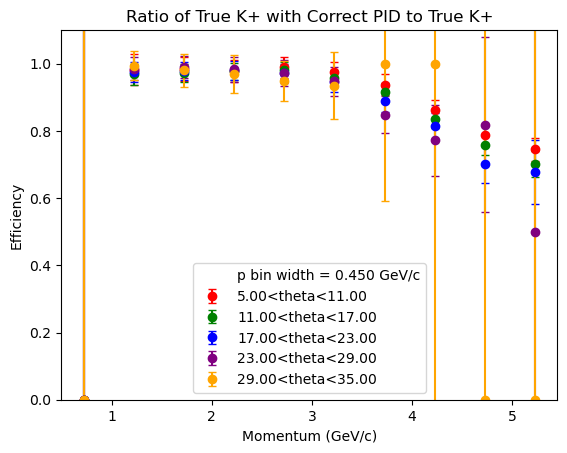

In [5]:
fig, ax = plt.subplots()
for i, (vals, errs) in enumerate(zip(valT, errT)):
    x = np.linspace(pStart, pEnd, len(vals)) + pStep/2

    ax.errorbar(
        x,
        vals,
        yerr=errs,
        fmt='o',
        color=colors[i],
        capsize=3,
        label=f"{(tStart+(i*tStep)):.2f}<theta<{(tStart+((i+1)*tStep)):.2f}"
    )
ax.set_ylim(0, 1.1)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Efficiency")
ax.set_title("Ratio of True K+ with Correct PID to True K+")
ax.plot([], [], ' ', label=f"p bin width = {pStep:.3f} GeV/c")
ax.legend()
fig.savefig(direct+"efficiencyKBaseline.png", dpi=150)
plt.show()

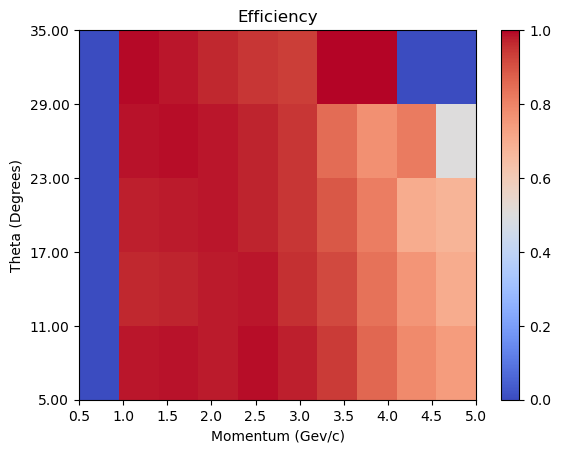

In [6]:
H = np.array(valT)  # shape = (t_bins, p_bins)

pbins = np.linspace(pStart, pEnd, H.shape[1] + 1)
tbins = np.linspace(tStart, tStart + len(valT)*tStep, H.shape[0] + 1)

fig, ax = plt.subplots()

pcm = ax.pcolormesh(
    pbins,
    tbins,
    H,
    cmap="coolwarm"
)

plt.colorbar(pcm, ax=ax)
ax.set_yticks(tbins)
ax.set_yticklabels([f"{t:.2f}" for t in tbins])
ax.set_xlabel("Momentum (Gev/c)")
ax.set_ylabel("Theta (Degrees)")
ax.set_title("Efficiency")
fig.savefig(direct+"efficiencyK2D.png", dpi=150)
plt.show()

In [7]:
#Contamination
t=tStart
valT = []
errT=[]
for i in range(tBins):
    print(t)
    thCut = matched[((matched["theta"]>=t)&(matched["theta"] < t+tStep))]
    #thCut = baseline[((baseline["theta"]>=t)&(baseline["theta"] < t+tStep))]
    vals =[]
    errs=[]
    p=pStart
    for j in range(pBins):
        label=f"plot {i}"
        pCut = thCut[((thCut["p"]>=p)&(thCut["p"] < p+pStep))]
        a= ((pCut["mc_matching_pid"]!=321) & (pCut["pid"]==321)).sum()
        b= (pCut["pid"]==321).sum()
        r=0
        rErr=99
        if b!=0:
            r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
        errs.append(rErr)
        vals.append(r)
        p = pStep+p
    t=t+tStep
    valT.append(vals)
    errT.append(errs)

5
11.0
17.0
23.0
29.0


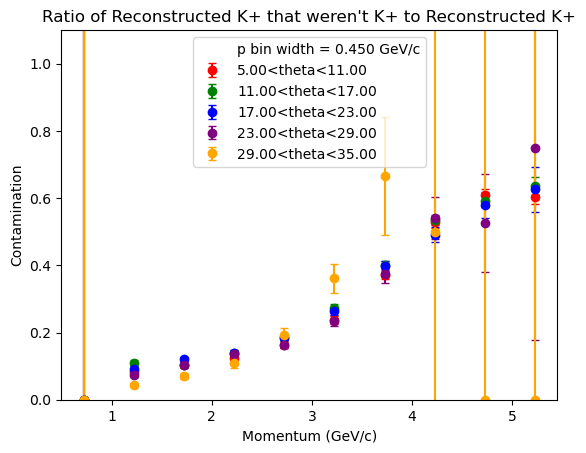

In [8]:
fig, ax = plt.subplots()

for i, (vals, errs) in enumerate(zip(valT, errT)):
    x = np.linspace(pStart, pEnd, len(vals)) + pStep/2

    ax.errorbar(
        x,
        vals,
        yerr=errs,
        fmt='o',
        color=colors[i],
        capsize=3,
        label=f"{(tStart+(i*tStep)):.2f}<theta<{(tStart+((i+1)*tStep)):.2f}"
    )
ax.set_ylim(0, 1.1)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Contamination")
ax.set_title("Ratio of Reconstructed K+ that weren't K+ to Reconstructed K+")
fig.savefig(direct + "contaminationKBaseline.png", dpi=150)
ax.plot([], [], ' ', label=f"p bin width = {pStep:.3f} GeV/c")
ax.legend()
plt.show()

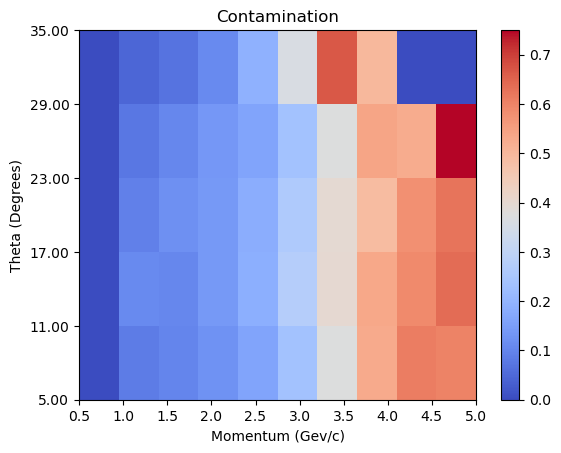

In [9]:
H = np.array(valT)  # shape = (t_bins, p_bins)

pbins = np.linspace(pStart, pEnd, H.shape[1] + 1)
tbins = np.linspace(tStart, tStart + len(valT)*tStep, H.shape[0] + 1)

fig, ax = plt.subplots()

pcm = ax.pcolormesh(
    pbins,
    tbins,
    H,
    cmap="coolwarm"
)

plt.colorbar(pcm, ax=ax)

ax.set_yticks(tbins)
ax.set_yticklabels([f"{t:.2f}" for t in tbins])

ax.set_xlabel("Momentum (Gev/c)")
ax.set_ylabel("Theta (Degrees)")
ax.set_title("Contamination")
fig.savefig(direct + "contaminationK2D.png", dpi=150)
plt.show()

In [10]:
#Purity
t=tStart
valT = []
errT=[]
for i in range(tBins):
    print(t)
    thCut = matched[((matched["theta"]>=t)&(matched["theta"] < t+tStep))]
    #thCut = baseline[((baseline["theta"]>=t)&(baseline["theta"] < t+tStep))]
    vals =[]
    errs=[]
    p=pStart
    for j in range(pBins):
        label=f"plot {i}"
        pCut = thCut[((thCut["p"]>=p)&(thCut["p"] < p+pStep))]
        a= ((pCut["mc_matching_pid"]==321) & (pCut["pid"]==321)).sum()
        b= (pCut["pid"]==321).sum()
        r=0
        rErr=99
        if b!=0:
            r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
        errs.append(rErr)
        vals.append(r)
        p = pStep+p
    t=t+tStep
    valT.append(vals)
    errT.append(errs)


5
11.0
17.0
23.0
29.0


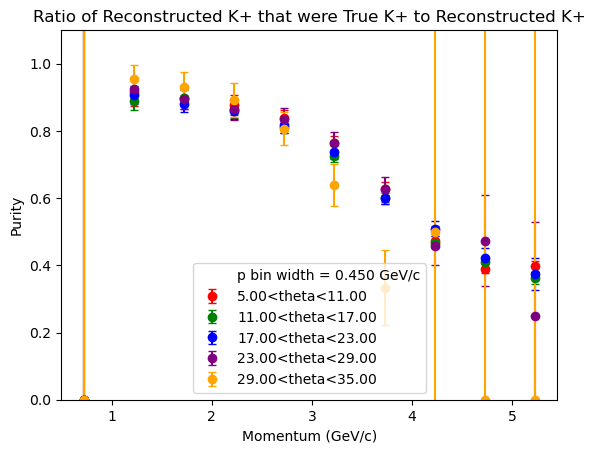

In [11]:
fig, ax = plt.subplots()

for i, (vals, errs) in enumerate(zip(valT, errT)):
    x = np.linspace(pStart, pEnd, len(vals)) + pStep/2

    ax.errorbar(
        x,
        vals,
        yerr=errs,
        fmt='o',
        color=colors[i],
        capsize=3,
        label=f"{(tStart+(i*tStep)):.2f}<theta<{(tStart+((i+1)*tStep)):.2f}"
    )
ax.set_ylim(0, 1.1)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Purity")
ax.set_title("Ratio of Reconstructed K+ that were True K+ to Reconstructed K+")
fig.savefig(direct + "purityKBaseline.png", dpi=150)
ax.plot([], [], ' ', label=f"p bin width = {pStep:.3f} GeV/c")
ax.legend()
plt.show()

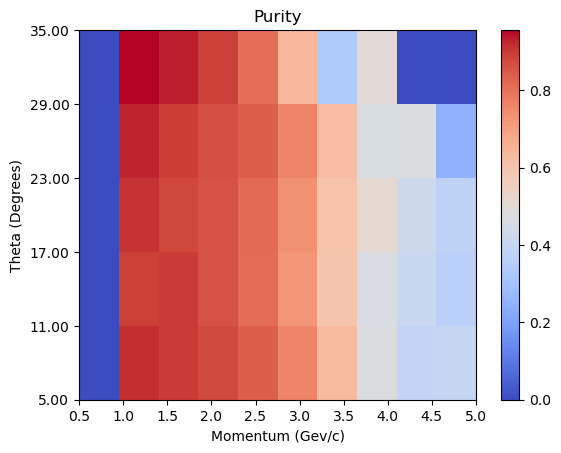

In [12]:
H = np.array(valT)  # shape = (t_bins, p_bins)

pbins = np.linspace(pStart, pEnd, H.shape[1] + 1)
tbins = np.linspace(tStart, tStart + len(valT)*tStep, H.shape[0] + 1)

fig, ax = plt.subplots()

pcm = ax.pcolormesh(
    pbins,
    tbins,
    H,
    cmap="coolwarm"
)

plt.colorbar(pcm, ax=ax)

ax.set_yticks(tbins)
ax.set_yticklabels([f"{t:.2f}" for t in tbins])

ax.set_xlabel("Momentum (Gev/c)")
ax.set_ylabel("Theta (Degrees)")
ax.set_title("Purity")
fig.savefig(direct + "purityK2D.png", dpi=150)
plt.show()

In [13]:
#Mis-Id
t=tStart
valT = []
errT=[]
for i in range(tBins):
    print(t)
    thCut = matched[((matched["theta"]>=t)&(matched["theta"] < t+tStep))]
    #thCut = baseline[((baseline["theta"]>=t)&(baseline["theta"] < t+tStep))]
    vals =[]
    errs=[]
    p=pStart
    for j in range(pBins):
        label=f"plot {i}"
        pCut = thCut[((thCut["p"]>=p)&(thCut["p"] < p+pStep))]
        a= ((pCut["mc_matching_pid"]==321) & (pCut["pid"]!=321)).sum()
        b= (pCut["mc_matching_pid"]==321).sum()
        r=0
        rErr=99
        if b!=0:
            r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
        errs.append(rErr)
        vals.append(r)
        p = pStep+p
    t=t+tStep
    valT.append(vals)
    errT.append(errs)

5
11.0
17.0
23.0
29.0


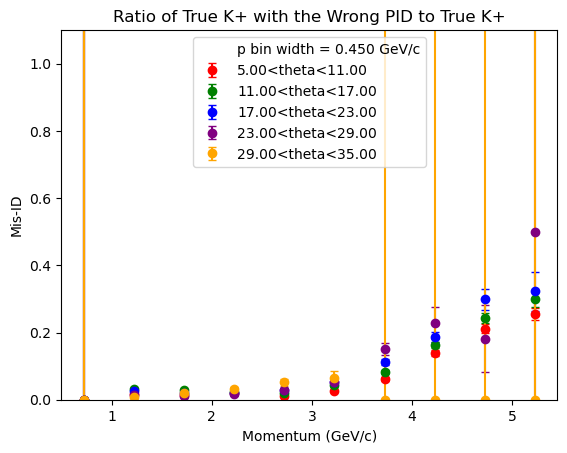

In [14]:
fig, ax = plt.subplots()

for i, (vals, errs) in enumerate(zip(valT, errT)):
    x = np.linspace(pStart, pEnd, len(vals)) + pStep/2

    ax.errorbar(
        x,
        vals,
        yerr=errs,
        fmt='o',
        color=colors[i],
        capsize=3,
        label=f"{(tStart+(i*tStep)):.2f}<theta<{(tStart+((i+1)*tStep)):.2f}"
    )
ax.set_ylim(0, 1.1)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Mis-ID")
ax.set_title("Ratio of True K+ with the Wrong PID to True K+")
fig.savefig(direct + "misIdKBaseline.png", dpi=150)
ax.plot([], [], ' ', label=f"p bin width = {pStep:.3f} GeV/c")
ax.legend()
plt.show()

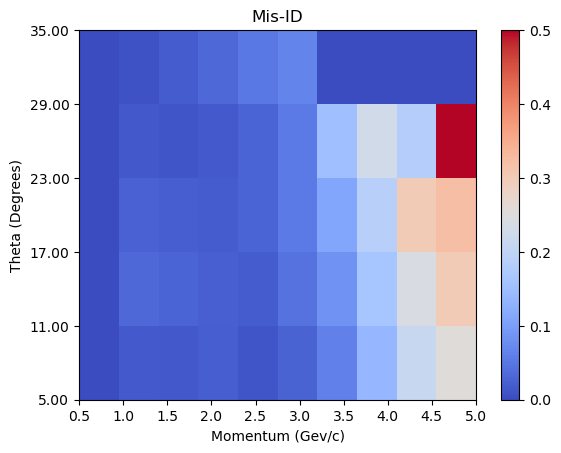

In [15]:
H = np.array(valT)  # shape = (t_bins, p_bins)

pbins = np.linspace(pStart, pEnd, H.shape[1] + 1)
tbins = np.linspace(tStart, tStart + len(valT)*tStep, H.shape[0] + 1)

fig, ax = plt.subplots()

pcm = ax.pcolormesh(
    pbins,
    tbins,
    H,
    cmap="coolwarm"
)

plt.colorbar(pcm, ax=ax)

ax.set_yticks(tbins)
ax.set_yticklabels([f"{t:.2f}" for t in tbins])

ax.set_xlabel("Momentum (Gev/c)")
ax.set_ylabel("Theta (Degrees)")
ax.set_title("Mis-ID")
fig.savefig(direct + "misIdK2D.png", dpi=150)
plt.show()